In [2]:

import msoffcrypto
import io
import pandas as pd

In [66]:

# Original password-protected file
input_file = "C:\\Users\\15145\\Desktop\\RBC Menthorship\\ANONYMIZED_WoodGreen_Client_Extract_All_Systems_27_October_2025.xlsx"
# Output file (decrypted copy)
output_file = "WoodGreen_Unlocked.xlsx"

# Unlock the file
with open(input_file, "rb") as f:
    office_file = msoffcrypto.OfficeFile(f)
    office_file.load_key(password="WgN7$eF!9rZq42pT")  # <---- Use the provided password
    with open(output_file, "wb") as out:
        office_file.decrypt(out)

print("File successfully decrypted and saved as:", output_file)

# Preview columns
df = pd.read_excel(output_file)
print("Columns:", df.columns.tolist())
print(df.head())

File successfully decrypted and saved as: WoodGreen_Unlocked.xlsx
Columns: ['Unique Record ID', 'Surname', 'First Given Name', 'Sex', 'Marital Status', 'Birth Date (YYMMDD)', 'Year of Birth', 'Month of Birth', 'Day of Birth', 'Birth Province / Country Code', 'Social Insurance Number', 'Provincial Health Insurance Number', 'Home Province Code', 'Home Address', 'Home Address Postal Code', 'Creation Date', 'Last Modified', 'System Registration', 'emailaddress1_DC', 'statecode_DC', 'mir_primary_phone_DC', 'modifiedon_DC', 'employmentstatus_DC', 'mir_workwithanyemployer_DC', 'mir_looking_for_work_DC', 'crmd_canadianexperience_DC', 'work_experience_DC', 'years_of_work_experience_DC', 'mir_minimum_one_year_experience_DC', 'mir_history_of_poor_work_retention_DC', 'mir_labor_market_change_DC', 'time_out_of_school_work_training_DC', 'mir_internationallytrainedprofessionals_DC', 'internationallytrainedtype_DC', 'primaryincomesource_DC', 'mir_lowincome_DC', 'mir_individual_monthly_income_after_tax

In [68]:
df = pd.read_excel("WoodGreen_Unlocked.xlsx")
df.to_csv("WoodGreen_All_Systems.csv", index=False)

In [72]:
employment_programs = [
    "integrated employment services",
    "employment accessibility services",
    "employment ontario",
    "personalized career accelerator (pca)",
    "older worker initiative",
    "youth job connections (yjc)",
    "youth job connections summer (yjc summer)",
    "newcomer youth career start (nycs)",
    "cnc/precision machining skills training program",
    "plumbing pre-apprenticeship level 1 program",
    "industrial millwright pre-apprenticeship program",
    "newcomer women entrepreneurship program",
    "tax skills for self-employed workers",
    "enhanced language training",
    "visual effects compositing program",
]

# Make a mask for rows whose program is in that list (case-insensitive)
mask = (
    df["program_name_DC"]
      .astype(str)          # avoid problems with NaN
      .str.strip()          # remove spaces
      .str.lower()
      .isin(employment_programs)
)

# Work on a copy to avoid SettingWithCopy warnings
df_emp = df.loc[mask].copy()


In [73]:
df_emp["Creation Date"] = pd.to_datetime(
    df_emp["Creation Date"],
    errors="coerce",              # invalid ones become NaT
    infer_datetime_format=True    # helps with performance / mixed formats
)


In [74]:
# Extract year
df_emp["Year"] = df_emp["Creation Date"].dt.year

# How many registrations per year?
registrations_by_year = (
    df_emp["Year"]
      .value_counts()
      .sort_index()
)

print(registrations_by_year)

print(f"\nTotal registrations: {len(df_emp)}")
print(f"Year range: {df_emp['Year'].min()} to {df_emp['Year'].max()}")


Year
2021     139
2022      65
2023     200
2024    2138
2025    1299
Name: count, dtype: int64

Total registrations: 3841
Year range: 2021 to 2025


In [75]:
df_emp["Creation Date"] = pd.to_datetime(
    df_emp["Creation Date"],
    errors="coerce",              # invalid ones become NaT
    infer_datetime_format=True    # helps with performance / mixed formats
)  

df_emp["Creation Date"] = pd.to_datetime(df_emp["Creation Date"], errors="coerce")


In [82]:
df_emp["Creation Date"] = pd.to_datetime(df_emp["Creation Date"], errors="coerce")

df_monthly = (
    df_emp
    .set_index("Creation Date")
    .resample("M")        # monthly
    .size()
    .rename("registrations")
)
df_monthly_2024 = df_monthly[df_monthly.index.year > 2023]

print(df_monthly)
print(df_monthly_2024)


Creation Date
2021-02-28    110
2021-03-31      3
2021-04-30      3
2021-05-31      4
2021-06-30      0
2021-07-31      3
2021-08-31      4
2021-09-30      4
2021-10-31      3
2021-11-30      4
2021-12-31      1
2022-01-31      3
2022-02-28      9
2022-03-31      5
2022-04-30     10
2022-05-31      1
2022-06-30      6
2022-07-31      2
2022-08-31      4
2022-09-30      3
2022-10-31      8
2022-11-30      6
2022-12-31      8
2023-01-31      5
2023-02-28     12
2023-03-31     19
2023-04-30     22
2023-05-31     12
2023-06-30      8
2023-07-31     24
2023-08-31     17
2023-09-30     29
2023-10-31     20
2023-11-30     21
2023-12-31     11
2024-01-31     52
2024-02-29     72
2024-03-31    119
2024-04-30    114
2024-05-31    171
2024-06-30    152
2024-07-31    538
2024-08-31    269
2024-09-30    217
2024-10-31    205
2024-11-30    178
2024-12-31     51
2025-01-31     38
2025-02-28     44
2025-03-31    200
2025-04-30    159
2025-05-31    128
2025-06-30    203
2025-07-31    156
2025-08-31    

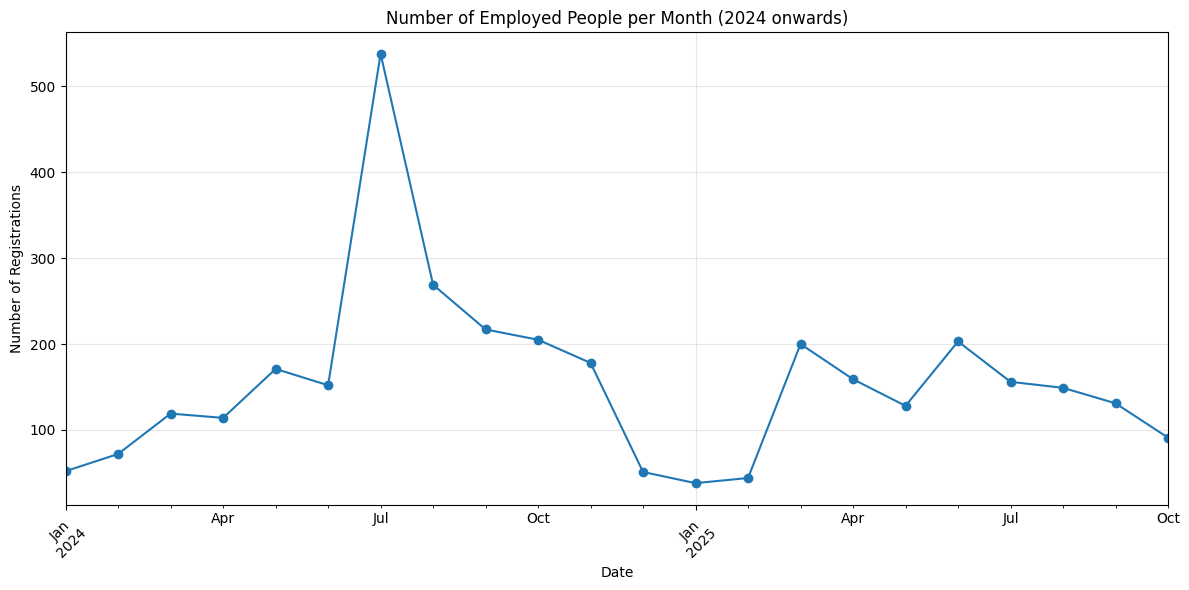

In [81]:
import matplotlib.pyplot as plt

# Filter for dates after 2024 (i.e., 2025 onwards)
df_monthly_2024 = df_monthly[df_monthly.index.year > 2023]

# Plot the filtered data
plt.figure(figsize=(12, 6))
df_monthly_2024.plot(kind='line', marker='o')
plt.title('Number of Employed People per Month (2024 onwards)')
plt.xlabel('Date')
plt.ylabel('Number of Registrations')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [84]:
# Export with column headers
df_monthly_2024.to_csv('monthly_registrations_2024.csv', header=True)

In [76]:
yearly_counts = df_emp['Year'].value_counts().sort_index()

print(f"\n{'='*60}")
print(f"EMPLOYMENT PROGRAM REGISTRATIONS BY YEAR")
print(f"{'='*60}\n")

for year, count in yearly_counts.items():
    print(f"{int(year):<10} {count:>8,} registrations")

print(f"\n{'='*60}")
print(f"TOTAL: {yearly_counts.sum():,} registrations")
print(f"{'='*60}")


EMPLOYMENT PROGRAM REGISTRATIONS BY YEAR

2021            139 registrations
2022             65 registrations
2023            200 registrations
2024          2,138 registrations
2025          1,299 registrations

TOTAL: 3,841 registrations


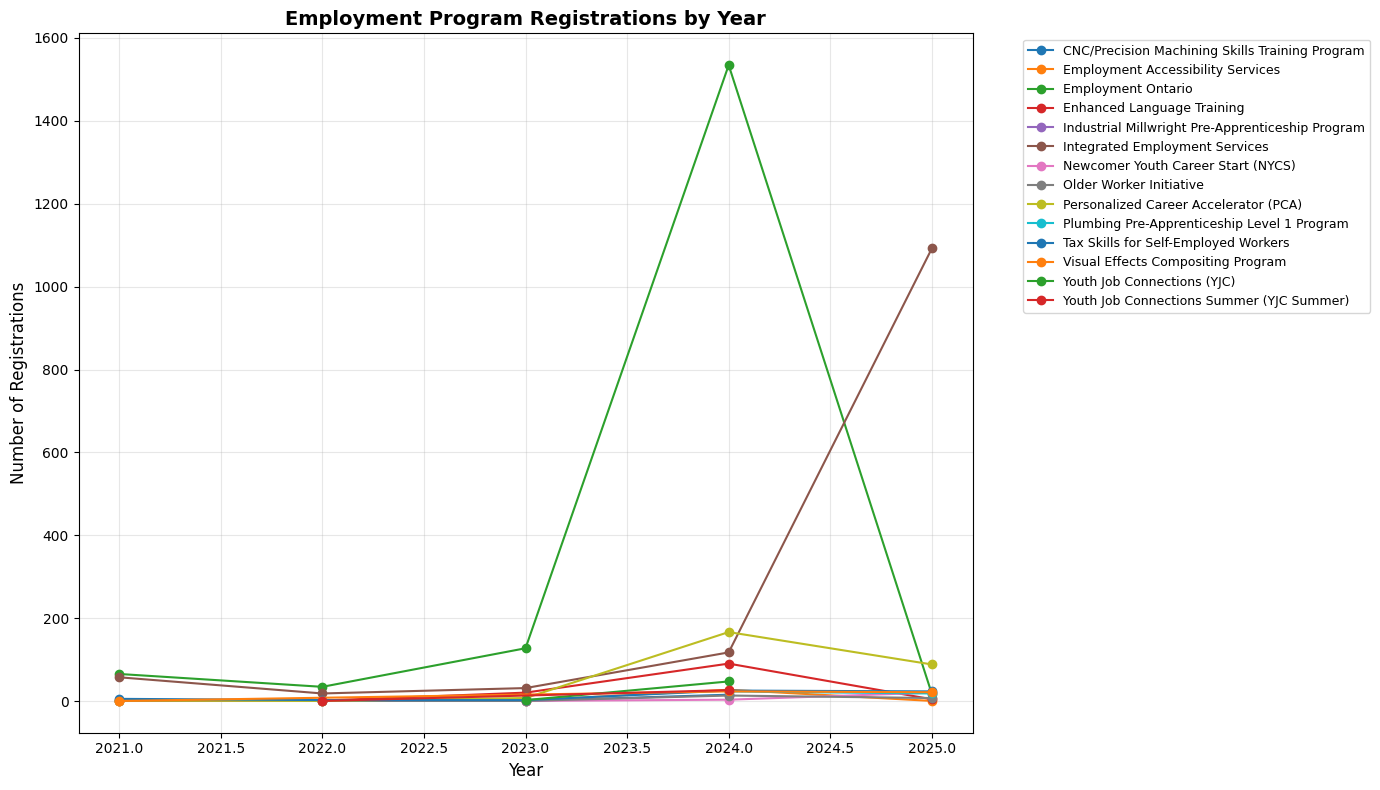

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
for program in registrations_by_prog_year['program_name_DC'].unique():
    program_data = registrations_by_prog_year[registrations_by_prog_year['program_name_DC'] == program]
    plt.plot(program_data['Year'], program_data['n_registrations'], marker='o', label=program)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Registrations', fontsize=12)
plt.title('Employment Program Registrations by Year', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

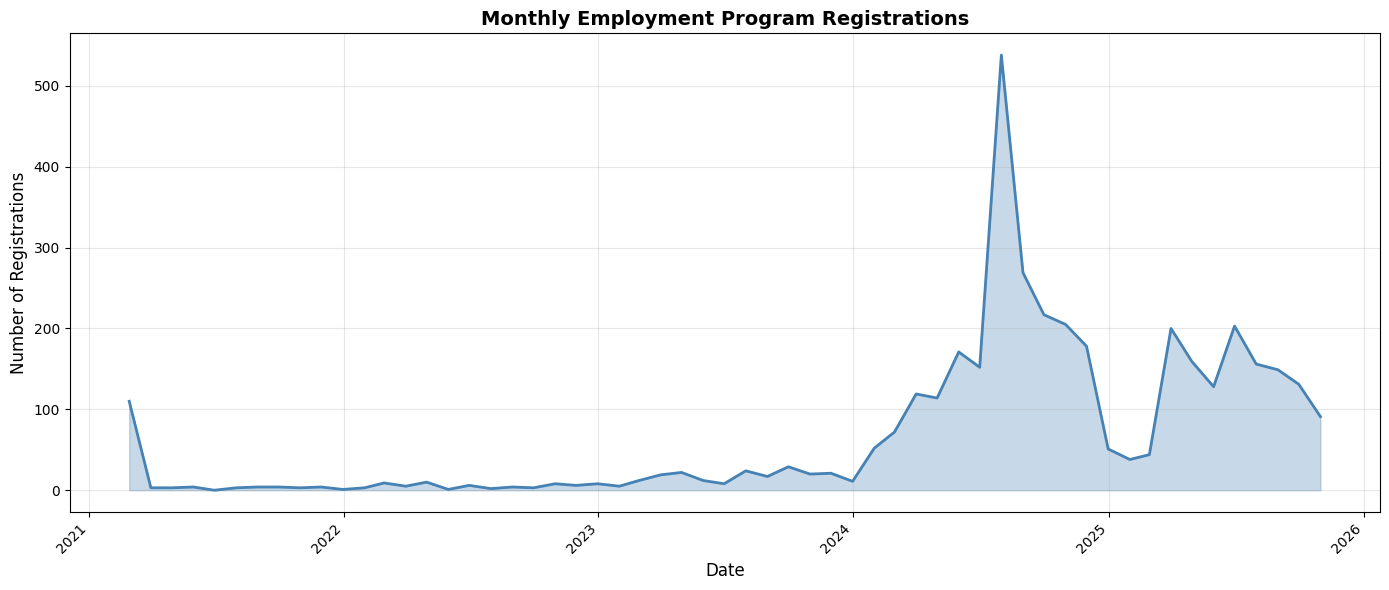

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_monthly.index, df_monthly.values, linewidth=2, color='steelblue')
ax.fill_between(df_monthly.index, df_monthly.values, alpha=0.3, color='steelblue')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Registrations', fontsize=12)
ax.set_title('Monthly Employment Program Registrations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

14:07:31 - cmdstanpy - INFO - Chain [1] start processing
14:07:31 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\15145\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


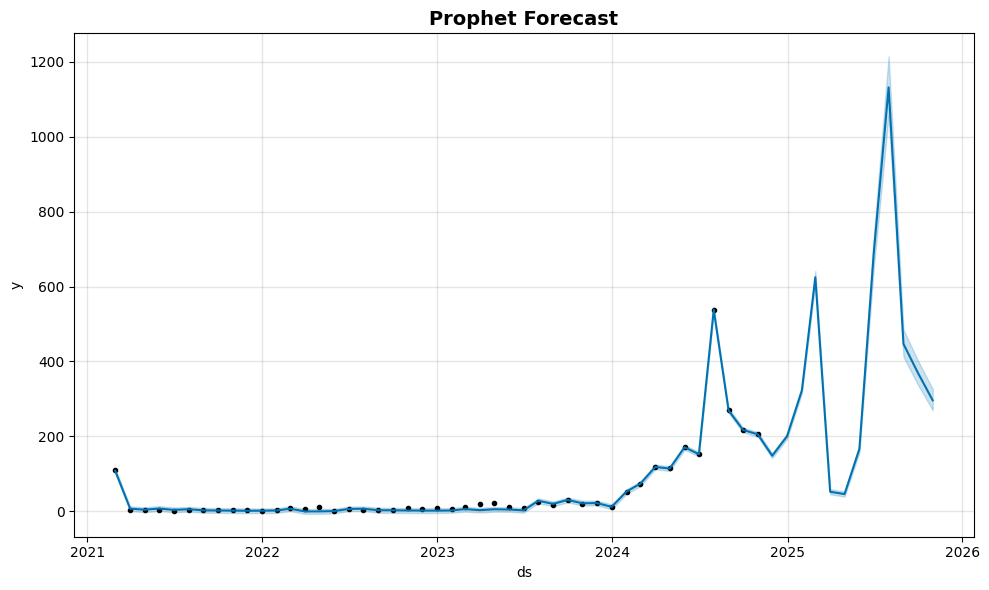

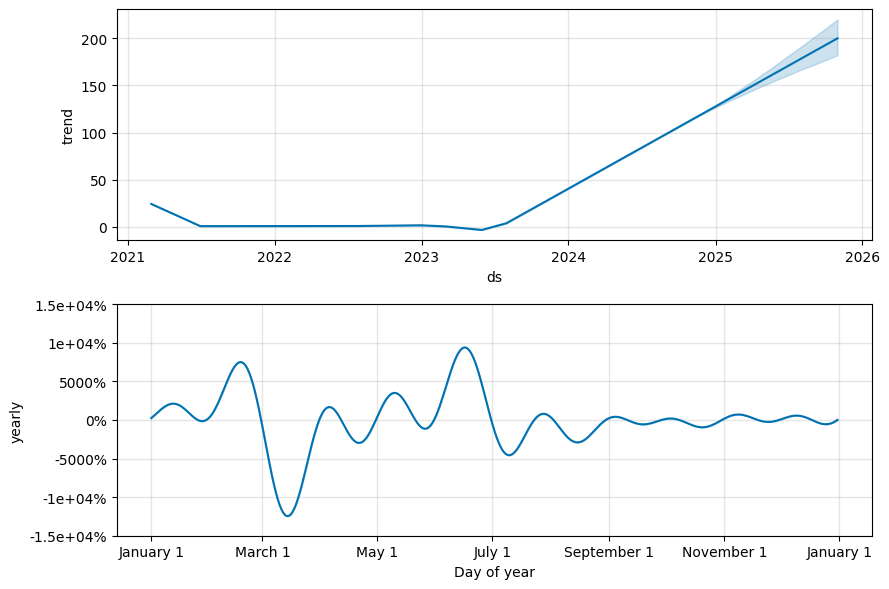


Prophet Performance:
MAE:  295.72
RMSE: 393.21


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for Prophet (needs 'ds' and 'y' columns)
prophet_data = pd.DataFrame({
    'ds': df_monthly.index,
    'y': df_monthly.values
})

# Split train/test
train_prophet = prophet_data[:-12]
test_prophet = prophet_data[-12:]

# Fit model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'  # or 'additive'
)
model.fit(train_prophet)

# Make predictions
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# Plot
fig = model.plot(forecast)
plt.title('Prophet Forecast', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot components (trend, seasonality)
fig = model.plot_components(forecast)
plt.tight_layout()
plt.show()

# Evaluate
forecast_test = forecast.iloc[-12:]['yhat'].values
mae = mean_absolute_error(test_prophet['y'], forecast_test)
rmse = np.sqrt(mean_squared_error(test_prophet['y'], forecast_test))

print(f"\nProphet Performance:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

In [40]:
# Cell 1: Imports & sanity checks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

# Inspect your monthly data
print("First 10:\n", df_monthly.head(10))
print("\nLast 10:\n", df_monthly.tail(10))
print("\nShape:", df_monthly.shape)


First 10:
 Creation Date
2021-02-28    110
2021-03-31      3
2021-04-30      3
2021-05-31      4
2021-06-30      0
2021-07-31      3
2021-08-31      4
2021-09-30      4
2021-10-31      3
2021-11-30      4
Freq: ME, Name: registrations, dtype: int64

Last 10:
 Creation Date
2025-01-31     38
2025-02-28     44
2025-03-31    200
2025-04-30    159
2025-05-31    128
2025-06-30    203
2025-07-31    156
2025-08-31    149
2025-09-30    131
2025-10-31     91
Freq: ME, Name: registrations, dtype: int64

Shape: (57,)


Time span: 2024-01-31 to 2025-10-31
Number of months: 22


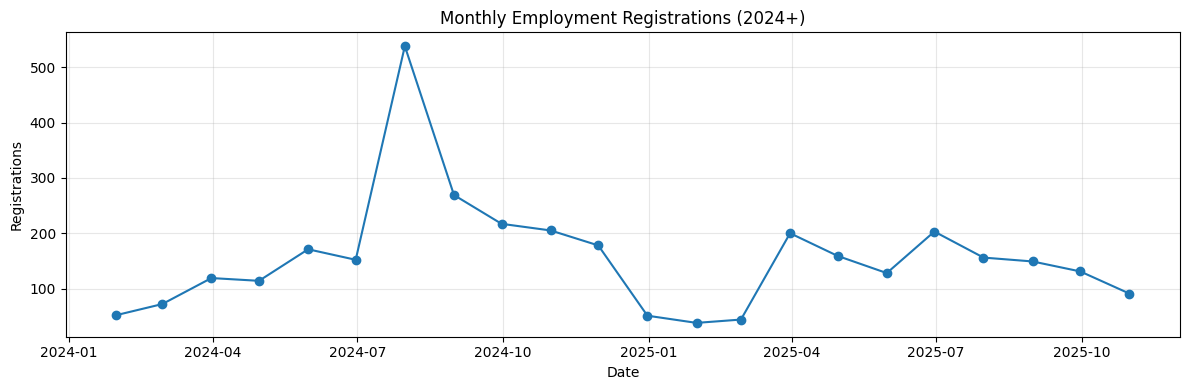

In [47]:
# Cell 2: Restrict to clean recent period (2024+)

START_DATE = "2024-01-01"

df_ts = df_monthly.copy()
df_ts.index = pd.to_datetime(df_ts.index)

# Keep only 2024-01-01 onward
df_ts = df_ts[df_ts.index >= START_DATE]

# Ensure monthly frequency (optional but nice)
df_ts = df_ts.asfreq("M")

print("Time span:", df_ts.index.min().date(), "to", df_ts.index.max().date())
print("Number of months:", len(df_ts))

plt.figure(figsize=(12, 4))
plt.plot(df_ts.index, df_ts.values, marker="o")
plt.title("Monthly Employment Registrations (2024+)")
plt.xlabel("Date")
plt.ylabel("Registrations")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [48]:
# Cell 3: Train/Test split (last HORIZON months = test)

HORIZON = 4  # change to 3 or 6 if you want

train = df_ts.iloc[:-HORIZON]
test = df_ts.iloc[-HORIZON:]

print("Train length:", len(train))
print("Test length:", len(test))

print("\nTrain range:", train.index.min().date(), "to", train.index.max().date())
print("Test range:", test.index.min().date(), "to", test.index.max().date())


Train length: 18
Test length: 4

Train range: 2024-01-31 to 2025-06-30
Test range: 2025-07-31 to 2025-10-31


In [49]:
# Cell 4: Non-seasonal SARIMA grid search (small, fast)

import itertools

p = d = q = range(0, 2)  # 0 or 1 for each
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_res = None

for order in pdq:
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)
        
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = order
            best_res = res
    except Exception as e:
        # You can print(e) if you want to debug
        continue

print("Best non-seasonal SARIMA order:", best_order)
print("Best AIC:", best_aic)


Best non-seasonal SARIMA order: (0, 1, 1)
Best AIC: 191.49240891245339


In [50]:
# Cell 5: Fit final SARIMA model with best order

final_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_res = final_model.fit(disp=False)

print(final_res.summary())


                               SARIMAX Results                                
Dep. Variable:          registrations   No. Observations:                   18
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 -93.746
Date:                Sat, 15 Nov 2025   AIC                            191.492
Time:                        14:35:08   BIC                            192.909
Sample:                    01-31-2024   HQIC                           191.477
                         - 06-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4468      0.329     -1.358      0.174      -1.092       0.198
sigma2      1.566e+04   3562.502      4.396      0.000    8678.035    2.26e+04
Ljung-Box (L1) (Q):                   0.00   Jarque-

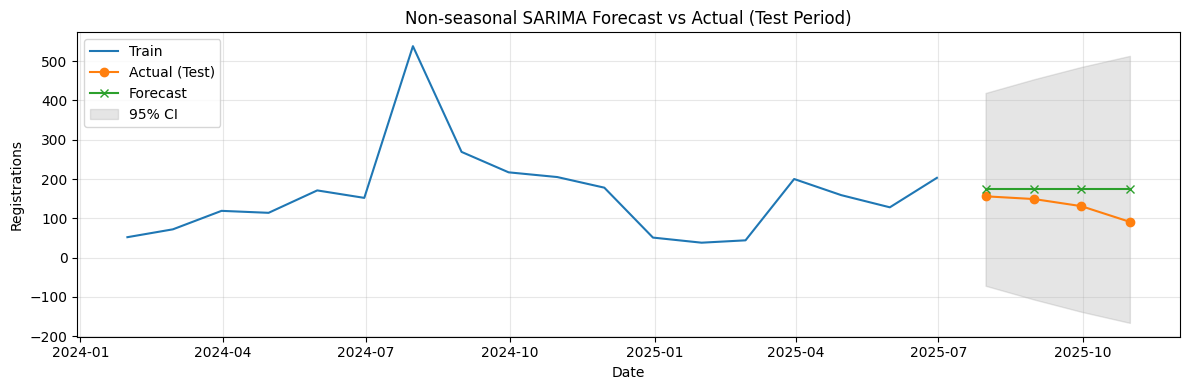

In [51]:
# Cell 6: Forecast HORIZON months and compare with test set

pred = final_res.get_forecast(steps=HORIZON)
forecast = pred.predicted_mean
conf_int = pred.conf_int()

# Align index with test
forecast.index = test.index
conf_int.index = test.index

plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual (Test)", marker="o")
plt.plot(forecast.index, forecast.values, label="Forecast", marker="x")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="gray",
    alpha=0.2,
    label="95% CI"
)

plt.title("Non-seasonal SARIMA Forecast vs Actual (Test Period)")
plt.xlabel("Date")
plt.ylabel("Registrations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [52]:
# Cell 7: Evaluate forecast performance

y_true = test.values
y_pred = forecast.values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Non-seasonal SARIMA Performance on Test Period:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


Non-seasonal SARIMA Performance on Test Period:
MAE:  41.90
RMSE: 48.91
MAPE: 37.81%


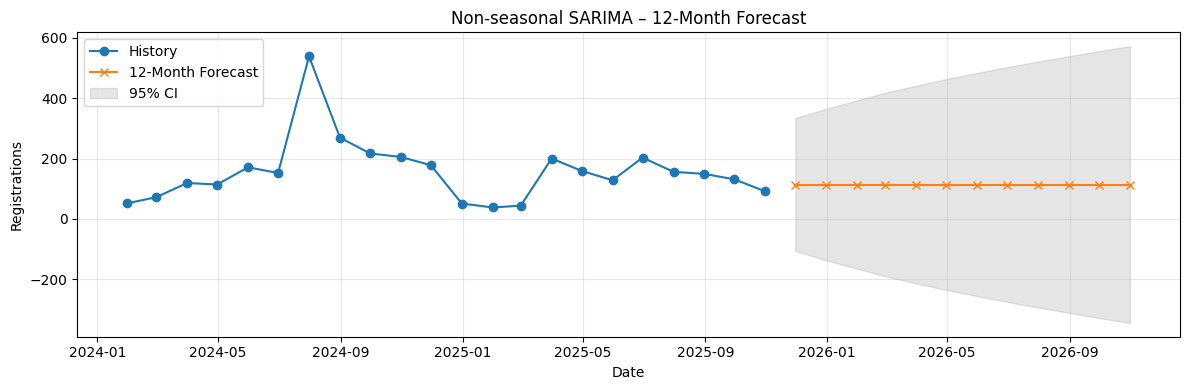

In [53]:
# Cell 8: Refit on full 2024+ data and forecast next 12 months

full_model = SARIMAX(
    df_ts,
    order=best_order,
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

full_res = full_model.fit(disp=False)

future_steps = 12
future_pred = full_res.get_forecast(steps=future_steps)

future_mean = future_pred.predicted_mean
future_ci = future_pred.conf_int()

future_index = pd.date_range(
    start=df_ts.index[-1] + pd.offsets.MonthEnd(1),
    periods=future_steps,
    freq="M"
)
future_mean.index = future_index
future_ci.index = future_index

plt.figure(figsize=(12, 4))
plt.plot(df_ts.index, df_ts.values, label="History", marker="o")
plt.plot(future_mean.index, future_mean.values, label="12-Month Forecast", marker="x")

plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    color="gray",
    alpha=0.2,
    label="95% CI"
)

plt.title("Non-seasonal SARIMA – 12-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Registrations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

